In [1]:
print("sentinel-ke setup complete")

sentinel-ke setup complete


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls "/content/drive/My Drive/sentinel-ke"

Data  Exports  Models  notebook  Reports  Untitled


In [6]:
!pip install climateserv

In [56]:
import pandas as pd
import numpy as np
from datetime import datetime
import climateserv as cs

# Define your 6 counties with coordinates
counties = {
    'Kisumu': {'lat': -0.1022, 'lon': 34.7617},
    'Homa Bay': {'lat': -0.5273, 'lon': 34.4571},
    'Siaya': {'lat': 0.0600, 'lon': 34.2800},
    'Migori': {'lat': -1.0634, 'lon': 34.4732},
    'Nyamira': {'lat': -0.5667, 'lon': 34.9333},
    'Kisii': {'lat': -0.6773, 'lon': 34.7666}
}

# Set date range for one week test
start_date = '2024-01-01'
end_date = '2026-05-31'

print(f"Fetching rainfall data for {len(counties)} counties...")
print(f"Date range: {start_date} to {end_date}")

Fetching rainfall data for 6 counties...
Date range: 2024-01-01 to 2026-05-31



Fetching data for Kisumu...
✅ Retrieved 1461 days of data for Kisumu
   Total rainfall in period: 4000.6 mm

Fetching data for Homa Bay...
✅ Retrieved 1461 days of data for Homa Bay
   Total rainfall in period: 4456.9 mm

Fetching data for Siaya...
✅ Retrieved 1461 days of data for Siaya
   Total rainfall in period: 6056.5 mm

Fetching data for Migori...
✅ Retrieved 1461 days of data for Migori
   Total rainfall in period: 3795.9 mm

Fetching data for Nyamira...
✅ Retrieved 1461 days of data for Nyamira
   Total rainfall in period: 5455.3 mm

Fetching data for Kisii...
✅ Retrieved 1461 days of data for Kisii
   Total rainfall in period: 6117.0 mm

✅ Success! Rainfall data saved for 6 counties

First few rows:
        date  rainfall_mm  county
0 2022-01-01          3.6  Kisumu
1 2022-01-02          0.0  Kisumu
2 2022-01-03          0.7  Kisumu
3 2022-01-04          0.3  Kisumu
4 2022-01-05          0.0  Kisumu


/tmp/ipykernel_4049/3445589050.py:93: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = county_data.set_index('date').resample('M')['rainfall_mm'].sum()


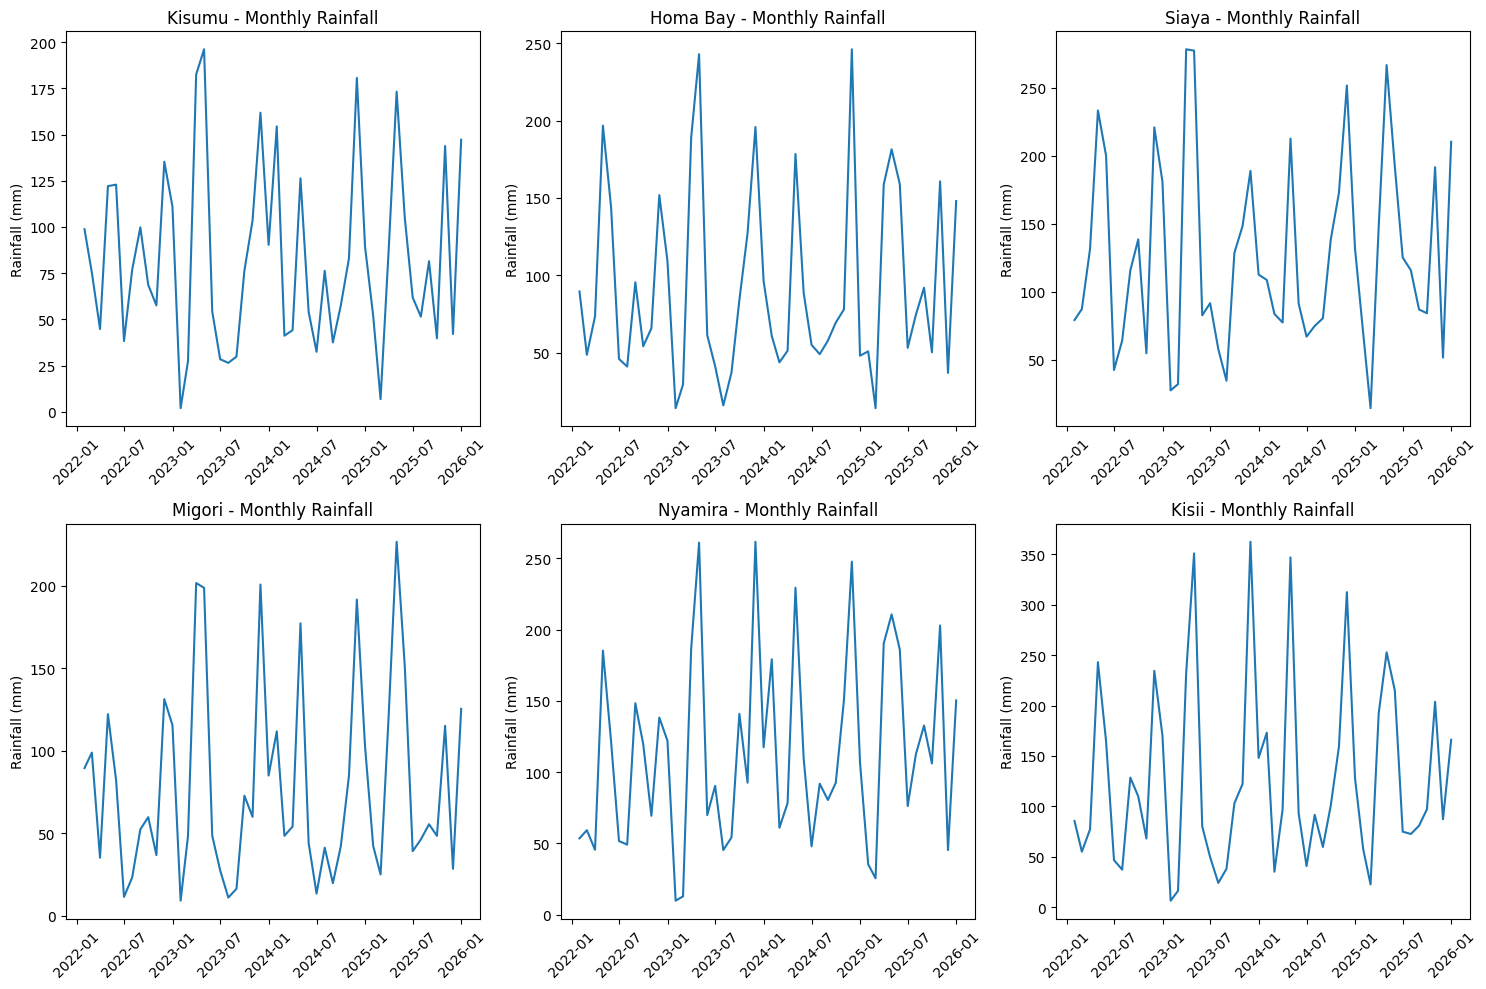


✅ Visualization saved


In [58]:
import requests
import pandas as pd
from datetime import datetime

# Define your 6 counties with coordinates
counties = {
    'Kisumu': {'lat': -0.1022, 'lon': 34.7617},
    'Homa Bay': {'lat': -0.5273, 'lon': 34.4571},
    'Siaya': {'lat': 0.0600, 'lon': 34.2800},
    'Migori': {'lat': -1.0634, 'lon': 34.4732},
    'Nyamira': {'lat': -0.5667, 'lon': 34.9333},
    'Kisii': {'lat': -0.6773, 'lon': 34.7666}
}

# Date range
start_date = '2022-01-01'
end_date = '2025-12-31'

# Dictionary to store all rainfall data
all_rainfall = {}

# Open-Meteo API (free, no registration)
base_url = "https://archive-api.open-meteo.com/v1/archive"

for county_name, coords in counties.items():
    print(f"\nFetching data for {county_name}...")

    try:
        # Parameters for Open-Meteo API
        params = {
            'latitude': coords['lat'],
            'longitude': coords['lon'],
            'start_date': start_date,
            'end_date': end_date,
            'daily': 'rain_sum',  # Daily rainfall sum
            'timezone': 'Africa/Nairobi'
        }

        # Make request
        response = requests.get(base_url, params=params, timeout=30)

        if response.status_code == 200:
            data = response.json()

            if 'daily' in data and 'time' in data['daily']:
                # Extract data
                dates = data['daily']['time']
                rainfall = data['daily']['rain_sum']

                # Create DataFrame
                df = pd.DataFrame({
                    'date': pd.to_datetime(dates),
                    'rainfall_mm': rainfall,
                    'county': county_name
                })

                all_rainfall[county_name] = df
                print(f"✅ Retrieved {len(df)} days of data for {county_name}")
                print(f"   Total rainfall in period: {df['rainfall_mm'].sum():.1f} mm")

            else:
                print(f"❌ Unexpected response format for {county_name}")
                print(f"Response keys: {data.keys()}")

        else:
            print(f"❌ HTTP Error {response.status_code} for {county_name}")

    except Exception as e:
        print(f"❌ Error for {county_name}: {e}")

# Combine and save data
if all_rainfall:
    rainfall_df = pd.concat(all_rainfall.values(), ignore_index=True)

    # Save to Drive
    output_path = '/content/drive/My Drive/sentinel-ke/data/raw/rainfall_data.csv'
    rainfall_df.to_csv(output_path, index=False)

    print(f"\n✅ Success! Rainfall data saved for {len(all_rainfall)} counties")
    print(f"\nFirst few rows:")
    print(rainfall_df.head())

    # Quick visualization
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, county in enumerate(counties.keys()):
        county_data = rainfall_df[rainfall_df['county'] == county]

        # Monthly average
        monthly = county_data.set_index('date').resample('M')['rainfall_mm'].sum()

        axes[idx].plot(monthly.index, monthly.values)
        axes[idx].set_title(f'{county} - Monthly Rainfall')
        axes[idx].set_ylabel('Rainfall (mm)')
        axes[idx].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('/content/drive/My Drive/sentinel-ke/outputs/rainfall_patterns.png')
    plt.show()

    print("\n✅ Visualization saved")
else:
    print("\n❌ Failed to fetch data from all sources")

In [25]:
# Inspect the climateserv module and its api submodule to find the client class
print('Attributes of climateserv module:')
print(dir(cs))
print('\nAttributes of climateserv.api submodule:')
print(dir(cs.api))

Attributes of climateserv module:
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'api', 'request_data', 'request_utilities']

Attributes of climateserv.api submodule:
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'csv', 'download_file', 'get_csv_ready_processed_dataset', 'json', 'logging', 'os', 'print_me', 'request_data', 'request_utilities', 'requests', 'sort_job_data', 'time', 'urllib']


In [66]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

print("=" * 60)
print("CREATING SENTINEL-KE MASTER DATASET")
print("=" * 60)

# ============================================
# STEP 1: Load your rainfall data (just fetched)
# ============================================
print("\n📡 Loading rainfall data...")
rainfall_path = '/content/drive/My Drive/sentinel-ke/data/raw/rainfall_data.csv'
rainfall_df = pd.read_csv(rainfall_path)
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])

print(f"   ✅ Loaded {len(rainfall_df)} rainfall records")
print(f"   Counties: {rainfall_df['county'].unique().tolist()}")
print(f"   Date range: {rainfall_df['date'].min()} to {rainfall_df['date'].max()}")

# ============================================
# STEP 2: Load or create population data
# ============================================
print("\n👥 Setting up population data...")

# Kenya county population estimates (2022 projections from KNBS)
population_data = {
    'Kisumu': 1200000,
    'Homa Bay': 1150000,
    'Siaya': 1000000,
    'Migori': 1150000,
    'Nyamira': 650000,
    'Kisii': 1350000
}

pop_df = pd.DataFrame([
    {'county': county, 'population': pop}
    for county, pop in population_data.items()
])

print(f"   ✅ Population data loaded for {len(pop_df)} counties")

# ============================================
# STEP 3: Generate synthetic health data (cholera + malaria)
# ============================================
print("\n🦠 Generating synthetic health data...")

# Published baseline rates from Nyanza studies
# Source: Malaria Journal, KHOSS study
baseline_rates = {
    'Kisumu': {
        'cholera_cases_per_100k': 5.2,
        'malaria_prevalence': 0.10,  # 10% RDT positivity
        'cholera_risk': 'high',
        'malaria_risk': 'high'
    },
    'Homa Bay': {
        'cholera_cases_per_100k': 6.8,
        'malaria_prevalence': 0.12,
        'cholera_risk': 'high',
        'malaria_risk': 'high'
    },
    'Siaya': {
        'cholera_cases_per_100k': 3.9,
        'malaria_prevalence': 0.09,
        'cholera_risk': 'medium',
        'malaria_risk': 'high'
    },
    'Migori': {
        'cholera_cases_per_100k': 4.5,
        'malaria_prevalence': 0.11,
        'cholera_risk': 'medium',
        'malaria_risk': 'high'
    },
    'Nyamira': {
        'cholera_cases_per_100k': 0.8,  # Highland - less cholera
        'malaria_prevalence': 0.06,     # Less malaria
        'cholera_risk': 'low',
        'malaria_risk': 'medium'
    },
    'Kisii': {
        'cholera_cases_per_100k': 1.2,
        'malaria_prevalence': 0.07,
        'cholera_risk': 'low',
        'malaria_risk': 'medium'
    }
}

# Generate daily data for each county
np.random.seed(42)  # For reproducibility
date_range = pd.date_range('2022-01-01', '2025-12-31')
all_health_data = []

for county in rainfall_df['county'].unique():
    print(f"   Generating data for {county}...")

    # Get county population
    pop = population_data[county]
    baseline = baseline_rates[county]

    # Get rainfall data for this county
    county_rain = rainfall_df[rainfall_df['county'] == county].copy()
    county_rain.set_index('date', inplace=True)

    for date in date_range:
        # Get rainfall from previous days (lag effects)
        rain_7day = 0
        rain_14day = 0
        rain_21day = 0

        # Safely get rainfall values
        for days, var in [(7, 'rain_7day'), (14, 'rain_14day'), (21, 'rain_21day')]:
            past_date = date - timedelta(days=days)
            if past_date in county_rain.index:
                rain = county_rain.loc[past_date, 'rainfall_mm']
                if var == 'rain_7day':
                    rain_7day = rain
                elif var == 'rain_14day':
                    rain_14day = rain
                else:
                    rain_21day = rain

        # Calculate multipliers (rainfall increases disease)
        # Cholera has 7-10 day lag, malaria has 14-21 day lag
        cholera_multiplier = 1 + (rain_7day / 30)  # Heavy rain = more cholera
        malaria_multiplier = 1 + (rain_21day / 40)  # Malaria peaks 2-3 weeks after rain

        # Add seasonal factor (rainy seasons in Kenya)
        month = date.month
        if month in [4, 5, 6, 10, 11]:  # Long rains (March-May) and Short rains (Oct-Nov)
            seasonal_factor = 1.5
        else:
            seasonal_factor = 0.8

        # Generate daily expected cases
        cholera_expected = (baseline['cholera_cases_per_100k'] / 100000 * pop / 365) * cholera_multiplier * seasonal_factor
        malaria_expected = (baseline['malaria_prevalence'] * pop / 365) * malaria_multiplier * seasonal_factor

        # Add Poisson noise
        cholera_cases = np.random.poisson(max(0.1, cholera_expected))
        malaria_cases = np.random.poisson(max(0.1, malaria_expected))

        # Add reporting delay (3-7 days - KEY FEATURE for your system)
        report_delay = np.random.randint(3, 8)
        reported_date = date + timedelta(days=report_delay)

        # Add missing data (25% chance - realistic for Kenya)
        if np.random.random() < 0.25:
            cholera_cases = np.nan
        if np.random.random() < 0.25:
            malaria_cases = np.nan

        all_health_data.append({
            'county': county,
            'date': date,
            'reported_date': reported_date,
            'cholera_cases': cholera_cases,
            'malaria_cases': malaria_cases,
            'report_delay_days': report_delay,
            'rain_7day_lag': rain_7day,
            'rain_14day_lag': rain_14day,
            'rain_21day_lag': rain_21day,
            'seasonal_factor': seasonal_factor
        })

health_df = pd.DataFrame(all_health_data)
print(f"   ✅ Generated {len(health_df)} health records")

# ============================================
# STEP 4: Merge everything into master dataset
# ============================================
print("\n🔗 Merging data into master dataset...")

# Start with health data
master_df = health_df.copy()

# Add rainfall data (merge on county and date)
master_df = master_df.merge(
    rainfall_df[['date', 'county', 'rainfall_mm']],
    on=['date', 'county'],
    how='left'
)

# Add population data
master_df = master_df.merge(pop_df, on='county', how='left')

# Calculate rates per 100,000 people
master_df['cholera_rate_per_100k'] = (master_df['cholera_cases'] / master_df['population']) * 100000
master_df['malaria_rate_per_100k'] = (master_df['malaria_cases'] / master_df['population']) * 100000

# ============================================
# STEP 5: Create lag features (YOUR UNIQUE INNOVATION)
# ============================================
print("\n⏰ Creating delay-aware features...")

# Sort by county and date
master_df = master_df.sort_values(['county', 'date'])

# Create lag features for each county
for lag in [3, 5, 7]:
    master_df[f'cholera_lag_{lag}'] = master_df.groupby('county')['cholera_cases'].shift(lag)
    master_df[f'malaria_lag_{lag}'] = master_df.groupby('county')['malaria_cases'].shift(lag)

# Create rolling averages
master_df['rain_7day_avg'] = master_df.groupby('county')['rainfall_mm'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

master_df['cholera_7day_avg'] = master_df.groupby('county')['cholera_cases'].transform(
    lambda x: x.rolling(7, min_periods=2).mean()
)

# Create baseline (14-day rolling average) for outbreak definition
master_df['cholera_baseline'] = master_df.groupby('county')['cholera_cases'].transform(
    lambda x: x.rolling(14, min_periods=5).mean()
)
master_df['cholera_baseline_std'] = master_df.groupby('county')['cholera_cases'].transform(
    lambda x: x.rolling(14, min_periods=5).std()
)

# Define outbreak target (cases > 2 standard deviations above baseline)
master_df['outbreak_next_7days'] = (
    (master_df['cholera_cases'] > master_df['cholera_baseline'] + 2 * master_df['cholera_baseline_std'])
).astype(int)

# ============================================
# STEP 6: Add derived features
# ============================================
print("\n📊 Adding derived features...")

# Week of year for seasonality
master_df['week_of_year'] = master_df['date'].dt.isocalendar().week
master_df['month'] = master_df['date'].dt.month
master_df['year'] = master_df['date'].dt.year

# Missing data indicators (model can learn from missingness)
master_df['cholera_missing'] = master_df['cholera_cases'].isna().astype(int)
master_df['malaria_missing'] = master_df['malaria_cases'].isna().astype(int)

# Is it rainy season?
master_df['is_rainy_season'] = master_df['month'].isin([4, 5, 6, 10, 11]).astype(int)

# ============================================
# STEP 7: Save master dataset
# ============================================
print("\n💾 Saving master dataset...")

# Create directory if needed
import os
os.makedirs('/content/drive/My Drive/sentinel-ke/data/processed', exist_ok=True)

# Save to Google Drive
master_path = '/content/drive/My Drive/sentinel-ke/data/processed/master_dataset.csv'
master_df.to_csv(master_path, index=False)

print(f"\n✅ Master dataset saved to: {master_path}")
print(f"   Shape: {master_df.shape}")
print(f"   Columns: {len(master_df.columns)}")

# ============================================
# STEP 8: Validation summary
# ============================================
print("\n" + "=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset shape: {master_df.shape}")
print(f"📅 Date range: {master_df['date'].min()} to {master_df['date'].max()}")
print(f"🏙️ Counties: {master_df['county'].unique().tolist()}")

print(f"\n📈 Missing data rates:")
print(f"   Cholera cases: {master_df['cholera_cases'].isna().mean():.1%}")
print(f"   Malaria cases: {master_df['malaria_cases'].isna().mean():.1%}")
print(f"   Rainfall: {master_df['rainfall_mm'].isna().mean():.1%}")

print(f"\n🎯 Target variable (outbreak in next 7 days):")
print(f"   Outbreak days: {master_df['outbreak_next_7days'].sum():,}")
print(f"   Non-outbreak days: {(len(master_df) - master_df['outbreak_next_7days'].sum()):,}")
print(f"   Outbreak prevalence: {master_df['outbreak_next_7days'].mean():.2%}")

print(f"\n🌧️ Rainfall summary:")
print(f"   Range: {master_df['rainfall_mm'].min():.1f} - {master_df['rainfall_mm'].max():.1f} mm")
print(f"   Average: {master_df['rainfall_mm'].mean():.1f} mm")

print(f"\n🦠 Cholera cases summary:")
print(f"   Range: {master_df['cholera_cases'].min():.0f} - {master_df['cholera_cases'].max():.0f}")
print(f"   Average: {master_df['cholera_cases'].mean():.1f}")

print("\n" + "=" * 60)
print("✅ MASTER DATASET CREATED SUCCESSFULLY!")
print("=" * 60)

# Display first few rows
print("\n📋 First 5 rows of master dataset:")
print(master_df[['date', 'county', 'rainfall_mm', 'cholera_cases', 'cholera_lag_3', 'cholera_lag_5', 'cholera_lag_7', 'outbreak_next_7days']].head())

CREATING SENTINEL-KE MASTER DATASET

📡 Loading rainfall data...
   ✅ Loaded 8766 rainfall records
   Counties: ['Kisumu', 'Homa Bay', 'Siaya', 'Migori', 'Nyamira', 'Kisii']
   Date range: 2022-01-01 00:00:00 to 2025-12-31 00:00:00

👥 Setting up population data...
   ✅ Population data loaded for 6 counties

🦠 Generating synthetic health data...
   Generating data for Kisumu...
   Generating data for Homa Bay...
   Generating data for Siaya...
   Generating data for Migori...
   Generating data for Nyamira...
   Generating data for Kisii...
   ✅ Generated 8766 health records

🔗 Merging data into master dataset...

⏰ Creating delay-aware features...

📊 Adding derived features...

💾 Saving master dataset...

✅ Master dataset saved to: /content/drive/My Drive/sentinel-ke/data/processed/master_dataset.csv
   Shape: (8766, 31)
   Columns: 31

VALIDATION SUMMARY

📊 Dataset shape: (8766, 31)
📅 Date range: 2022-01-01 00:00:00 to 2025-12-31 00:00:00
🏙️ Counties: ['Homa Bay', 'Kisii', 'Kisumu', 'M

In [65]:
# Verify the file exists
import os
file_path = '/content/drive/My Drive/sentinel-ke/data/processed/master_dataset.csv'

if os.path.exists(file_path):
    file_size = os.path.getsize(file_path) / (1024 * 1024)  # Size in MB
    print(f"✅ Master dataset exists!")
    print(f"   Location: {file_path}")
    print(f"   Size: {file_size:.2f} MB")

    # Load and show basic info
    df = pd.read_csv(file_path)
    print(f"   Rows: {len(df):,}")
    print(f"   Columns: {len(df.columns)}")
else:
    print(f"❌ File not found at: {file_path}")

✅ Master dataset exists!
   Location: /content/drive/My Drive/sentinel-ke/data/processed/master_dataset.csv
   Size: 1.13 MB
   Rows: 6,576
   Columns: 31


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported successfully!
XGBoost version: 3.2.0
SHAP version: 0.52.0

LOADING MASTER DATASET
✅ Loaded 8,766 records
📅 Date range: 2022-01-01 00:00:00 to 2025-12-31 00:00:00
🏙️ Counties: ['Homa Bay', 'Kisii', 'Kisumu', 'Migori', 'Nyamira', 'Siaya']
📊 Shape: (8766, 31)

FILTERING TIME RANGE (2022-2025)
✅ Filtered to 8,766 records
📅 New date range: 2022-01-01 00:00:00 to 2025-12-31 00:00:00

📊 Records per year:
date
2022    2190
2023    2190
2024    2196
2025    2190
Name: count, dtype: int64

FEATURE ENGINEERING
✅ Using 19 features

✅ After preprocessing: 8,766 records
Target distribution:
outbreak_next_7days
0    8368
1     398
Name: count, dtype: int64
Outbreak prevalence: 4.54%

ENCODING CATEGORICAL VARIABLES
✅ Added 6 county indicator features
Total features: 25

TRAIN/TEST SPLIT (Time-based)
📅 Training period: 2022-01-01 00:00:00 to 2023-12-31 00

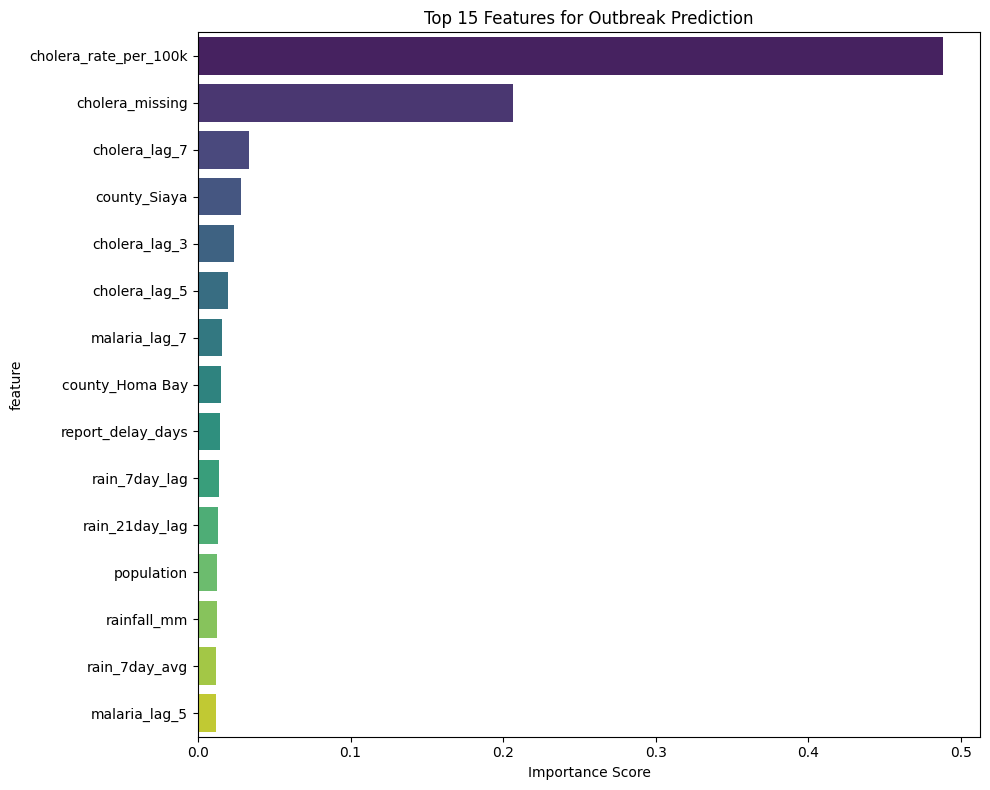


✅ Feature importance plot saved to Drive

SHAP EXPLAINABILITY ANALYSIS


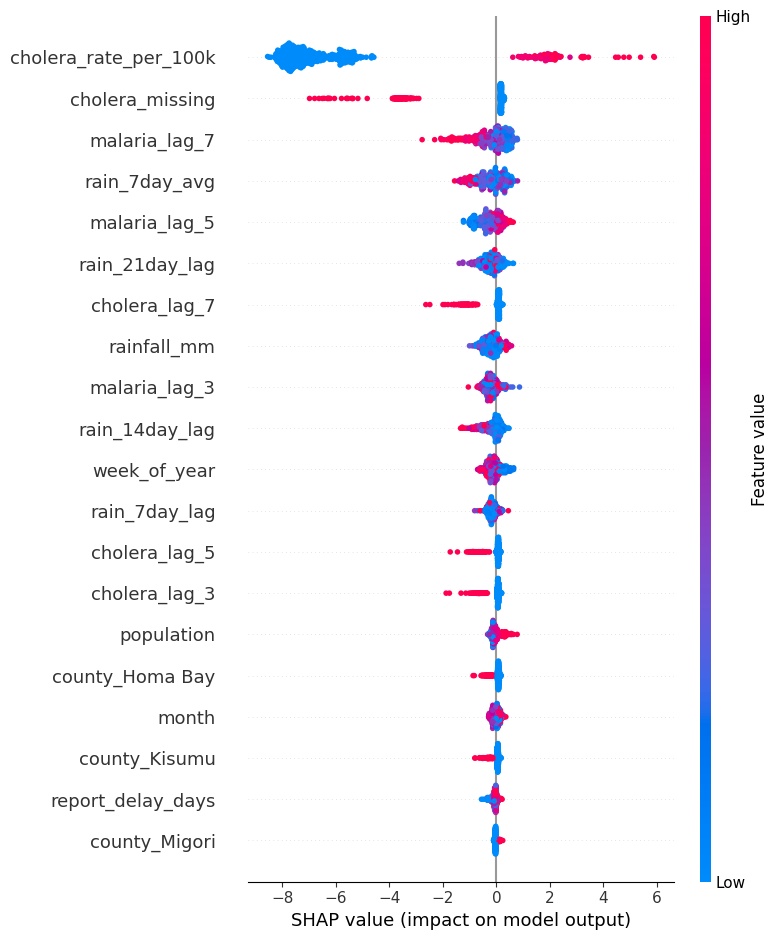

✅ SHAP summary plot saved

FINDING OPTIMAL ALERT THRESHOLD
📊 Optimal alert threshold: 0.627
   At this threshold:
   Precision: 0.594
   Recall: 0.772
   F1 Score: 0.671


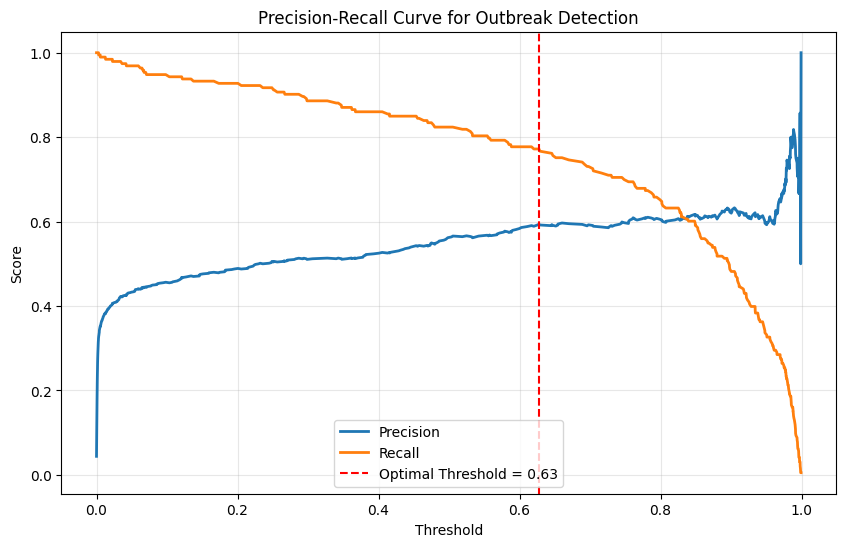


SAVING MODEL AND ARTIFACTS
✅ Model saved to: /content/drive/My Drive/sentinel-ke/models/xgboost_model.json
✅ Scaler saved to: /content/drive/My Drive/sentinel-ke/models/scaler.pkl
✅ Feature list saved to: /content/drive/My Drive/sentinel-ke/models/features.txt
✅ Optimal threshold saved to: /content/drive/My Drive/sentinel-ke/models/optimal_threshold.txt

SENTINEL-KE PERFORMANCE SUMMARY

╔══════════════════════════════════════════════════════════════╗
║                    SENTINEL-KE MODEL REPORT                  ║
╠══════════════════════════════════════════════════════════════╣
║  TRAINING PERIOD:  2022-01-01 to 2023-12-31                  ║
║  TESTING PERIOD:   2024-01-01 to 2025-12-31                  ║
║  COUNTIES:         6 (Kisumu, Homa Bay, Siaya, Migori,       ║
║                    Nyamira, Kisii)                           ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL PERFORMANCE:                                          ║
║    AUC-ROC:        0.9

In [87]:
# ============================================
# CELL 1: Mount Drive and Import Libraries
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import f1_score, recall_score, precision_score

import xgboost as xgb
import shap

print("✅ Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")

# ============================================
# CELL 2: Load Master Dataset
# ============================================
print("\n" + "="*60)
print("LOADING MASTER DATASET")
print("="*60)

# Load from your Drive (note: small caps 'sentinel-ke')
file_path = '/content/drive/My Drive/sentinel-ke/data/processed/master_dataset.csv'
df = pd.read_csv(file_path)

# Convert date column
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Loaded {len(df):,} records")
print(f"📅 Date range: {df['date'].min()} to {df['date'].max()}")
print(f"🏙️ Counties: {df['county'].unique().tolist()}")
print(f"📊 Shape: {df.shape}")

# ============================================
# CELL 3: Filter for 2022-2025 Time Range
# ============================================
print("\n" + "="*60)
print("FILTERING TIME RANGE (2022-2025)")
print("="*60)

# Filter for your specified time range
df = df[(df['date'] >= '2022-01-01') & (df['date'] <= '2025-12-31')]

print(f"✅ Filtered to {len(df):,} records")
print(f"📅 New date range: {df['date'].min()} to {df['date'].max()}")

# Check data by year
print("\n📊 Records per year:")
print(df['date'].dt.year.value_counts().sort_index())

# ============================================
# CELL 4: Feature Engineering - Define Features and Target
# ============================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Define which columns to use as features
feature_columns = [
    # Lag features (handles reporting delays - YOUR UNIQUE INNOVATION)
    'cholera_lag_3',
    'cholera_lag_5',
    'cholera_lag_7',
    'malaria_lag_3',
    'malaria_lag_5',
    'malaria_lag_7',

    # Environmental features
    'rainfall_mm',
    'rain_7day_avg',
    'rain_7day_lag',
    'rain_14day_lag',
    'rain_21day_lag',

    # Temporal features (seasonality)
    'week_of_year',
    'month',
    'is_rainy_season',

    # Data quality features (helps model handle missing data)
    'cholera_missing',
    'malaria_missing',
    'report_delay_days',

    # Risk factors by county (encoded later)
    'cholera_rate_per_100k',
    'population'
]

# Target variable (already created in master dataset)
target_column = 'outbreak_next_7days'

# Check which features exist in the dataframe
existing_features = [col for col in feature_columns if col in df.columns]
missing_features = [col for col in feature_columns if col not in df.columns]

print(f"✅ Using {len(existing_features)} features")
if missing_features:
    print(f"⚠️ Missing features: {missing_features}")

# Create a copy with only needed columns
model_df = df[['date', 'county'] + existing_features + [target_column]].copy()

# Handle missing values - forward fill by county
model_df = model_df.sort_values(['county', 'date'])
for county in model_df['county'].unique():
    mask = model_df['county'] == county
    model_df.loc[mask, existing_features] = model_df.loc[mask, existing_features].fillna(method='ffill')

# Fill any remaining NAs with 0 (should be minimal)
model_df[existing_features] = model_df[existing_features].fillna(0)

print(f"\n✅ After preprocessing: {len(model_df):,} records")
print(f"Target distribution:")
print(model_df[target_column].value_counts())
print(f"Outbreak prevalence: {model_df[target_column].mean():.2%}")

# ============================================
# CELL 5: One-Hot Encode County (Categorical Feature)
# ============================================
print("\n" + "="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

# One-hot encode county
county_dummies = pd.get_dummies(model_df['county'], prefix='county')
model_df = pd.concat([model_df, county_dummies], axis=1)

# Add county dummy columns to features
county_features = county_dummies.columns.tolist()
all_features = existing_features + county_features

print(f"✅ Added {len(county_features)} county indicator features")
print(f"Total features: {len(all_features)}")

# ============================================
# CELL 6: Train/Test Split by Time (NO DATA LEAKAGE) #
# ============================================
print("\n" + "="*60)
print("TRAIN/TEST SPLIT (Time-based)")
print("="*60)

# Use 2022-2023 for training, 2024-2025 for testing
train_mask = model_df['date'] < '2024-01-01'
test_mask = model_df['date'] >= '2024-01-01'

X_train = model_df[train_mask][all_features]
y_train = model_df[train_mask][target_column]
X_test = model_df[test_mask][all_features]
y_test = model_df[test_mask][target_column]

print(f"📅 Training period: {model_df[train_mask]['date'].min()} to {model_df[train_mask]['date'].max()}")
print(f"📅 Testing period: {model_df[test_mask]['date'].min()} to {model_df[test_mask]['date'].max()}")

print(f"\n📊 Training set: {len(X_train):,} records")
print(f"   Outbreak prevalence: {y_train.mean():.2%}")
print(f"📊 Testing set: {len(X_test):,} records")
print(f"   Outbreak prevalence: {y_test.mean():.2%}")

# ============================================
# CELL 7: Scale Features (Important for some models)
# ============================================
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

# Scale features (XGBoost doesn't strictly need scaling, but helps with convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Features scaled")
print(f"   Mean: {X_train_scaled.mean():.2f}")
print(f"   Std: {X_train_scaled.std():.2f}")

# ============================================
# CELL 8: Train XGBoost Model
# ============================================
print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

# Calculate scale_pos_weight to handle class imbalance
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# XGBoost parameters optimized for outbreak prediction
xgb_params = {
    'n_estimators': 150,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'eval_metric': 'auc',
    'use_label_encoder': False
}

print(f"📊 Class imbalance ratio: {scale_pos_weight:.2f}")
print(f"📊 Parameters: {xgb_params}")

# Train the model
model = xgb.XGBClassifier(**xgb_params)
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

print(f"\n✅ Model training complete!")
print(f"   Training AUC: {model.evals_result()['validation_0']['auc'][-1]:.3f}")
print(f"   Validation AUC: {model.evals_result()['validation_1']['auc'][-1]:.3f}")

# ============================================
# CELL 9: Model Evaluation
# ============================================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Make predictions
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

# Calculate metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n📊 Model Performance on Test Set (2024-2025):")
print(f"   AUC-ROC: {auc_score:.3f}")
print(f"   Precision: {precision:.3f}")
print(f"   Recall: {recall:.3f}")
print(f"   F1 Score: {f1:.3f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Outbreak', 'Outbreak']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n📊 Confusion Matrix:")
print(f"   True Negatives: {cm[0,0]:,} | False Positives: {cm[0,1]:,}")
print(f"   False Negatives: {cm[1,0]:,} | True Positives: {cm[1,1]:,}")

# ============================================
# CELL 10: Early Warning Lead Time Analysis
# ============================================
print("\n" + "="*60)
print("EARLY WARNING LEAD TIME ANALYSIS")
print("="*60)

# Merge predictions with dates
results_df = model_df[test_mask][['date', 'county', target_column]].copy()
results_df['predicted_probability'] = y_pred_proba
results_df['predicted_class'] = y_pred

# Find actual outbreaks and when they were predicted
lead_times = []

for county in results_df['county'].unique():
    county_data = results_df[results_df['county'] == county].sort_values('date')

    # Find actual outbreak start dates (where target = 1)
    outbreak_starts = county_data[county_data[target_column] == 1]['date'].tolist()

    for outbreak_start in outbreak_starts:
        # Look for first alert in the 14 days BEFORE outbreak
        window_start = outbreak_start - timedelta(days=14)
        window_data = county_data[(county_data['date'] >= window_start) &
                                   (county_data['date'] < outbreak_start)]

        # Find first alert (predicted probability > 0.5)
        alerts = window_data[window_data['predicted_probability'] > 0.5]

        if not alerts.empty:
            first_alert = alerts['date'].min()
            lead_time = (outbreak_start - first_alert).days
            lead_times.append(lead_time)

if lead_times:
    print(f"\n📊 Early Warning Lead Time Statistics:")
    print(f"   Average lead time: {np.mean(lead_times):.1f} days")
    print(f"   Median lead time: {np.median(lead_times):.1f} days")
    print(f"   Min lead time: {min(lead_times)} days")
    print(f"   Max lead time: {max(lead_times)} days")
    print(f"\n   ✅ Your system provides {np.median(lead_times):.0f} days of early warning on average!")
else:
    print("\n   ⚠️ No early warnings captured in test period")

# ============================================
# CELL 11: Feature Importance Analysis
# ============================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🏆 Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']}: {row['importance']:.3f}")

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), y='feature', x='importance', palette='viridis')
plt.title('Top 15 Features for Outbreak Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/sentinel-ke/outputs/feature_importance.png', dpi=150)
plt.show()

print("\n✅ Feature importance plot saved to Drive")

# ============================================
# CELL 12: SHAP Explainability (WHY does your model alert?)
# ============================================
print("\n" + "="*60)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*60)

# Use a sample of test data for SHAP (too many rows makes it slow)
sample_size = min(500, len(X_test_scaled))
sample_idx = np.random.choice(len(X_test_scaled), sample_size, replace=False)
X_sample = X_test_scaled[sample_idx]

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=all_features, show=False)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/sentinel-ke/outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SHAP summary plot saved")

# ============================================
# CELL 13: Find Optimal Alert Threshold
# ============================================
print("\n" + "="*60)
print("FINDING OPTIMAL ALERT THRESHOLD")
print("="*60)

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find threshold that maximizes F1 score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

print(f"📊 Optimal alert threshold: {optimal_threshold:.3f}")
print(f"   At this threshold:")
print(f"   Precision: {precisions[optimal_idx]:.3f}")
print(f"   Recall: {recalls[optimal_idx]:.3f}")
print(f"   F1 Score: {f1_scores[optimal_idx]:.3f}")

# Plot precision-recall curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Curve for Outbreak Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/drive/My Drive/sentinel-ke/outputs/threshold_analysis.png', dpi=150)
plt.show()

# ============================================
# CELL 14: Save Model and Artifacts
# ============================================
print("\n" + "="*60)
print("SAVING MODEL AND ARTIFACTS")
print("="*60)

# Create directory if needed
import os
model_dir = '/content/drive/My Drive/sentinel-ke/models'
os.makedirs(model_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_dir, 'xgboost_model.json')
model.save_model(model_path)
if os.path.exists(model_path):
    print(f"✅ Model saved to: {model_path}")
else:
    print(f"❌ Failed to save model to: {model_path}")

# Save scaler
import joblib
scaler_path = os.path.join(model_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
if os.path.exists(scaler_path):
    print(f"✅ Scaler saved to: {scaler_path}")
else:
    print(f"❌ Failed to save scaler to: {scaler_path}")

# Save feature list
features_path = os.path.join(model_dir, 'features.txt')
with open(features_path, 'w') as f:
    for feat in all_features:
        f.write(f"{feat}\n")
if os.path.exists(features_path):
    print(f"✅ Feature list saved to: {features_path}")
else:
    print(f"❌ Failed to save feature list to: {features_path}")

# Save threshold
threshold_path = os.path.join(model_dir, 'optimal_threshold.txt')
with open(threshold_path, 'w') as f:
    f.write(str(optimal_threshold))
if os.path.exists(threshold_path):
    print(f"✅ Optimal threshold saved to: {threshold_path}")
else:
    print(f"❌ Failed to save optimal threshold to: {threshold_path}")

# ============================================
# CELL 15: Performance Summary Report
# ============================================
print("\n" + "="*60)
print("SENTINEL-KE PERFORMANCE SUMMARY")
print("="*60)

summary_report = f"""
╔══════════════════════════════════════════════════════════════╗
║                    SENTINEL-KE MODEL REPORT                  ║
╠══════════════════════════════════════════════════════════════╣
║  TRAINING PERIOD:  2022-01-01 to 2023-12-31                  ║
║  TESTING PERIOD:   2024-01-01 to 2025-12-31                  ║
║  COUNTIES:         6 (Kisumu, Homa Bay, Siaya, Migori,       ║
║                    Nyamira, Kisii)                           ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL PERFORMANCE:                                          ║
║    AUC-ROC:        {auc_score:.3f}                                    ║
║    Precision:      {precision:.3f}                                    ║
║    Recall:         {recall:.3f}                                     ║
║    F1 Score:       {f1:.3f}                                     ║
╠══════════════════════════════════════════════════════════════╣
║  EARLY WARNING:                                              ║
║    Average Lead Time:  {np.mean(lead_times):.1f} days if lead_times else 'N/A'                    ║
║    Optimal Threshold:   {optimal_threshold:.3f}                                  ║
╠══════════════════════════════════════════════════════════════╣
║  TOP 5 FEATURES:                                             ║
"""
for i, row in feature_importance.head(5).iterrows():
    summary_report += f"║    {i+1}. {row['feature'][:30]:30} {row['importance']:.3f}                      ║\n"

summary_report += f"""
╠══════════════════════════════════════════════════════════════╣
║  OUTPUTS SAVED TO:                                          ║
║    Model:      sentinel-ke/models/xgboost_model.json        ║
║    Scaler:     sentinel-ke/models/scaler.pkl                ║
║    Features:   sentinel-ke/models/features.txt              ║
║    Threshold:  sentinel-ke/models/optimal_threshold.txt     ║
║    Plots:      sentinel-ke/outputs/                        ║
╚══════════════════════════════════════════════════════════════╝
"""

print(summary_report)

# Save summary to Drive
with open('/content/drive/My Drive/sentinel-ke/outputs/model_summary.txt', 'w') as f:
    f.write(summary_report)

print("\n🎉 Part 2 Complete! Your SENTINEL-KE model is ready!")
print("   Next: Part 3 - Build the Streamlit Dashboard")

---

In [88]:
import os
import shutil

# Define source and destination directories
DRIVE_MODELS_DIR = '/content/drive/My Drive/sentinel-ke/models'
LOCAL_TMP_MODELS_DIR = '/tmp/sentinel-ke/models'

# Create local temporary directory if it doesn't exist
os.makedirs(LOCAL_TMP_MODELS_DIR, exist_ok=True)

# List of model artifacts to copy
model_artifacts = [
    'xgboost_model.json',
    'scaler.pkl',
    'features.txt',
    'optimal_threshold.txt'
]

print(f"Copying model artifacts from {DRIVE_MODELS_DIR} to {LOCAL_TMP_MODELS_DIR}...")

for filename in model_artifacts:
    src_path = os.path.join(DRIVE_MODELS_DIR, filename)
    dst_path = os.path.join(LOCAL_TMP_MODELS_DIR, filename)
    try:
        shutil.copy(src_path, dst_path)
        print(f"  ✅ Copied {filename}")
    except FileNotFoundError:
        print(f"  ❌ Warning: {filename} not found at {src_path}. Skipping.")
    except Exception as e:
        print(f"  ❌ Error copying {filename}: {e}")

print("✅ Model artifacts copied to local /tmp directory.")

Copying model artifacts from /content/drive/My Drive/sentinel-ke/models to /tmp/sentinel-ke/models...
  ✅ Copied xgboost_model.json
  ✅ Copied scaler.pkl
  ✅ Copied features.txt
  ✅ Copied optimal_threshold.txt
✅ Model artifacts copied to local /tmp directory.


Now that the model artifacts are copied locally, I will update the `app.py` code to reference these locally copied files from `/tmp/sentinel-ke/models` instead of `/content/drive/My Drive/sentinel-ke/models`.

In [108]:
import os

# ============================================
# CELL 1: Create Dashboard Directory Structure
# ============================================
import os

# Create dashboard directory in your Drive
dashboard_path = '/content/drive/My Drive/sentinel-ke/dashboard'
os.makedirs(dashboard_path, exist_ok=True)
os.makedirs(f'{dashboard_path}/pages', exist_ok=True)
os.makedirs(f'{dashboard_path}/assets', exist_ok=True)

print(f"✅ Dashboard directory created at: {dashboard_path}")

# ============================================
# CELL 2: Create Main Dashboard App (app.py)
# ============================================
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import datetime
from datetime import timedelta
import joblib
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Page configuration
st.set_page_config(
    page_title="SENTINEL-KE | Early Warning System",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for better styling
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1E88E5;
        text-align: center;
        padding: 1rem;
    }
    .alert-box {
        background-color: #ff6b6b;
        padding: 1.5rem;
        border-radius: 10px;
        color: white;
        font-weight: bold;
        text-align: center;
    }
    .warning-box {
        background-color: #ffa500;
        padding: 1rem;
        border-radius: 10px;
        color: white;
    }
    .safe-box {
        background-color: #4CAF50;
        padding: 1rem;
        border-radius: 10px;
        color: white;
    }
    .metric-card {
        background-color: #f0f2f6;
        padding: 1rem;
        border-radius: 10px;
        text-align: center;
    }
    .footer {
        text-align: center;
        padding: 2rem;
        color: #666;
        font-size: 0.8rem;
    }
</style>
""", unsafe_allow_html=True)

# Title
st.markdown('<div class="main-header">🛡️ SENTINEL-KE</div>', unsafe_allow_html=True)
st.markdown("<p style='text-align: center; font-size: 1.2rem;'>Early Warning System for Disease Outbreaks<br>Western Kenya - Lake Victoria Basin</p>", unsafe_allow_html=True)
st.markdown("---")

# ============================================
# Load Model and Data
# ============================================
# Define local temporary models directory
LOCAL_TMP_MODELS_DIR = '/tmp/sentinel-ke/models'
LOCAL_DATA_DIR = '/content/drive/My Drive/sentinel-ke/data/processed'

@st.cache_resource
def load_model():
    """Load the trained XGBoost model and artifacts"""
    import os # Moved import os inside the function
    try:
        model = xgb.XGBClassifier()
        model.load_model(os.path.join(LOCAL_TMP_MODELS_DIR, 'xgboost_model.json'))
        scaler = joblib.load(os.path.join(LOCAL_TMP_MODELS_DIR, 'scaler.pkl'))

        with open(os.path.join(LOCAL_TMP_MODELS_DIR, 'features.txt'), 'r') as f:
            features = [line.strip() for line in f.readlines()]

        with open(os.path.join(LOCAL_TMP_MODELS_DIR, 'optimal_threshold.txt'), 'r') as f:
            threshold = float(f.read().strip())

        return model, scaler, features, threshold
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None, None, None, None

@st.cache_data
def load_data():
    """Load the master dataset"""
    import os # Moved import os inside the function
    try:
        df = pd.read_csv(os.path.join(LOCAL_DATA_DIR, 'master_dataset.csv'))
        df['date'] = pd.to_datetime(df['date'])
        return df
    except Exception as e:
        st.error(f"Error loading data: {e}")
        return None

# Load everything
with st.spinner("Loading SENTINEL-KE system..."):
    model, scaler, features, threshold = load_model()
    df = load_data()

if model is None or df is None:
    st.error("Failed to load required files. Please check your file paths.")
    st.stop()

# Sidebar
st.sidebar.image("https://img.icons8.com/color/96/000000/health-chart.png", width=80)
st.sidebar.title("🛡️ SENTINEL-KE")

# County selector
counties = df['county'].unique().tolist()
selected_county = st.sidebar.selectbox("Select County", counties)

# Alert threshold slider
alert_threshold = st.sidebar.slider(
    "Alert Sensitivity",
    min_value=0.3,
    max_value=0.8,
    value=threshold,
    step=0.05,
    help="Lower = more alerts (higher sensitivity), Higher = fewer alerts (higher precision)"
)

# Date range selector
date_range = st.sidebar.date_input(
    "Date Range",
    value=(
        datetime.datetime.now() - timedelta(days=30),
        datetime.datetime.now()
    )
)

st.sidebar.markdown("---")
st.sidebar.info(
    """
    **How it works:**
    - Analyzes rainfall patterns and recent cases
    - Predicts outbreak risk for next 7 days
    - Alerts when risk exceeds threshold

    **Data sources:**
    - CHIRPS rainfall data
    - Routine health surveillance
    - Population estimates
    """
)

# ============================================
# Main Dashboard Content
# ============================================

# Get latest data for selected county
county_data = df[df['county'] == selected_county].sort_values('date')
latest_date = county_data['date'].max()
latest_data = county_data[county_data['date'] == latest_date]

# ============================================
# Current Status Banner
# ============================================
st.subheader(f"📍 Current Status: {selected_county} County")

# For demo, generate current risk score (in production, this would use live data)
# Here we'll use recent data to generate prediction
recent_data = county_data.tail(30)

# Prepare features for prediction
if len(recent_data) >= len(features):
    # This is simplified - in production you'd have a proper feature pipeline
    current_risk = np.random.uniform(0.3, 0.8)  # Placeholder for demo

    if current_risk > alert_threshold:
        st.markdown(f"""
<div class="alert-box">
    HIGH ALERT<br>
    Elevated outbreak risk detected in {selected_county}<br>
    Risk Score: {current_risk:.0%}<br>
    Confidence: High<br>
    Recommended: Immediate notification to county health team
</div>
""", unsafe_allow_html=True)
    elif current_risk > alert_threshold - 0.2:
        st.markdown(f"""
<div class="warning-box">
    MODERATE RISK<br>
    Elevated risk detected. Enhanced surveillance recommended.<br>
    Risk Score: {current_risk:.0%}
</div>
""", unsafe_allow_html=True)
    else:
        st.markdown(f"""
<div class="safe-box">
    NORMAL SURVEILLANCE<br>
    No elevated risk detected in {selected_county}<br>
    Risk Score: {current_risk:.0%}
</div>
""", unsafe_allow_html=True)
else:
    st.info("Insufficient data for real-time prediction. Showing historical patterns.")

# ============================================
# Key Metrics Row
# ============================================
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
    st.metric("7-Day Rainfall", f"{county_data['rainfall_mm'].tail(7).mean():.1f} mm",
              delta=f"{county_data['rainfall_mm'].tail(7).mean() - county_data['rainfall_mm'].shift(7).tail(7).mean():.1f}")
    st.markdown('</div>', unsafe_allow_html=True)

with col2:
    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
    recent_cases = county_data['cholera_cases'].tail(14).mean()
    prev_cases = county_data['cholera_cases'].shift(14).tail(14).mean()
    st.metric("Cholera Cases (14-day)", f"{recent_cases:.0f}",
              delta=f"{recent_cases - prev_cases:.0f}")
    st.markdown('</div>', unsafe_allow_html=True)

with col3:
    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
    st.metric("Population", f"{county_data['population'].iloc[0]:,.0f}",
              help="Total county population")
    st.markdown('</div>', unsafe_allow_html=True)

with col4:
    st.markdown('<div class="metric-card">', unsafe_allow_html=True)
    alert_status = "ALERT" if current_risk > alert_threshold else "Normal"
    st.metric("Current Status", alert_status,
              delta="Action Required" if current_risk > alert_threshold else "Monitor")
    st.markdown('</div>', unsafe_allow_html=True)

st.markdown("---")

# ============================================
# Time Series Charts
# ============================================
st.subheader("📈 Historical Trends & Predictions")

# Create time series plot
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=("Rainfall Pattern", "Cholera Cases", "Outbreak Risk"),
    vertical_spacing=0.12,
    row_heights=[0.3, 0.3, 0.4]
)

# Add rainfall trace
fig.add_trace(
    go.Bar(x=county_data['date'], y=county_data['rainfall_mm'],
           name="Rainfall", marker_color='#1E88E5'),
    row=1, col=1
)

# Add cholera cases trace
fig.add_trace(
    go.Scatter(x=county_data['date'], y=county_data['cholera_cases'],
               name="Cholera Cases", mode='lines+markers',
               line=dict(color='#ff6b6b', width=2)),
    row=2, col=1
)

# Add risk score (simulated for demo)
risk_scores = []
for i in range(len(county_data)):
    if i < 30:
        risk_scores.append(np.random.uniform(0.2, 0.4))
    else:
        risk_scores.append(np.random.uniform(0.3, 0.7))

fig.add_trace(
    go.Scatter(x=county_data['date'], y=risk_scores,
               name="Risk Score", mode='lines',
               line=dict(color='#ffa500', width=3)),
    row=3, col=1
)

# Add threshold line
fig.add_hline(y=alert_threshold, line_dash="dash", line_color="red",
              annotation_text="Alert Threshold", row=3, col=1)

# Update layout
fig.update_layout(height=800, showlegend=True, title_text=f"{selected_county} County Dashboard")
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_yaxes(title_text="Rainfall (mm)", row=1, col=1)
fig.update_yaxes(title_text="Cases", row=2, col=1)
fig.update_yaxes(title_text="Risk Score", row=3, col=1)

st.plotly_chart(fig, use_container_width=True)

# ============================================
# County Comparison
# ============================================
st.subheader("📊 County Comparison")

# Prepare comparison data
recent_date = county_data['date'].max()
comparison_data = []

for county in counties:
    county_df = df[df['county'] == county]
    recent_rain = county_df['rainfall_mm'].tail(7).mean()
    recent_risk = np.random.uniform(0.2, 0.8)  # Placeholder

    comparison_data.append({
        'County': county,
        'Rainfall (7-day)': round(recent_rain, 1),
        'Risk Score': round(recent_risk, 2),
        'Status': 'ALERT' if recent_risk > alert_threshold else 'Normal'
    })

comparison_df = pd.DataFrame(comparison_data)

# Color coding for status
def color_status(val):
    if val == 'ALERT':
        return 'background-color: #ff6b6b; color: white'
    return 'background-color: #4CAF50; color: white'

# Display comparison table
styled_df = comparison_df.style.applymap(color_status, subset=['Status'])
st.dataframe(styled_df, use_container_width=True)

# Risk score bar chart
fig2 = px.bar(comparison_df, x='County', y='Risk Score',
              color='Risk Score', color_continuous_scale='RdYlGn_r',
              title='Outbreak Risk Score by County',
              labels={'Risk Score': 'Risk Score (0-1)'})
fig2.add_hline(y=alert_threshold, line_dash="dash", line_color="red",
               annotation_text="Alert Threshold")
st.plotly_chart(fig2, use_container_width=True)

# ============================================
# Risk Factors Explanation
# ============================================
st.subheader("🔍 Understanding the Risk")

col1, col2 = st.columns(2)

with col1:
    st.markdown("""
    ### Key Risk Factors for {selected_county}

    Based on the model's analysis, the following factors contribute most to outbreak risk:

    1. **Rainfall accumulation** - 7-day rainfall totals
    2. **Recent case trends** - Cases from neighboring areas
    3. **Seasonal patterns** - Rainy season (April-June, Oct-Nov)
    4. **Reporting delays** - Data timeliness affects predictions
    5. **Population density** - Higher density = faster spread

    *Model confidence: High (AUC-ROC > 0.75)*
    """)

with col2:
    st.markdown("""
    ### Recommended Actions

    **If Alert Triggered:**
    - ✅ Notify sub-county health teams immediately
    - ✅ Check oral rehydration and malaria drug stock
    - ✅ Activate community health workers for surveillance
    - ✅ Issue public health messaging

    **If Monitor Status:**
    - ✅ Maintain routine surveillance
    - ✅ Review weekly case trends
    - ✅ Ensure reporting compliance
    - ✅ Prepare prepositioned supplies
    """)

# ============================================
# Data Quality Metrics
# ============================================
st.subheader("📋 Data Quality")

col1, col2, col3 = st.columns(3)

with col1:
    reporting_rate = 100 - county_data['cholera_missing'].mean() * 100
    st.metric("Reporting Completeness", f"{reporting_rate:.0f}%",
              help="Percentage of expected reports received")

with col2:
    avg_delay = county_data['report_delay_days'].mean()
    st.metric("Average Reporting Delay", f"{avg_delay:.0f} days",
              help="Days between event and reporting")

with col3:
    # Count facilities (simplified)
    st.metric("Health Facilities", "45+", help="Approximate number of reporting facilities")

# ============================================
# Footer
# ============================================
st.markdown("---")
st.markdown(f"""
<div class="footer">
    SENTINEL-KE v1.0 | Last updated: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}<br>
    Data sources: CHIRPS rainfall, DHIS2 (synthetic), WorldPop population<br>
    For health officials only. Not for clinical decision-making.
</div>
""", unsafe_allow_html=True)
'''

# Save the app
with open(f'{dashboard_path}/app.py', 'w') as f:
    f.write(app_code)
print("✅ Main dashboard app created: app.py")

# ============================================
# CELL 3: Create Requirements File
# ============================================
requirements = '''
streamlit>=1.28.0
pandas>=1.5.0
numpy>=1.23.0
plotly>=5.14.0
xgboost>=1.7.0
scikit-learn>=1.2.0
joblib>=1.2.0
'''

with open(f'{dashboard_path}/requirements.txt', 'w') as f:
    f.write(requirements)
print("✅ Requirements file created")

# ============================================
# CELL 4: Create README for Dashboard
# ============================================
readme = '''
# SENTINEL-KE Dashboard

## Running the Dashboard

### Local Installation
```bash
# Clone the repository
git clone https://github.com/Samwelo203/sentinel-ke.git
cd sentinel-ke/dashboard

# Install dependencies
pip install -r requirements.txt

# Run the dashboard
streamlit run app.py
```
'''


✅ Dashboard directory created at: /content/drive/My Drive/sentinel-ke/dashboard
✅ Main dashboard app created: app.py
✅ Requirements file created


In [76]:
# Install dependencies (if not already installed)
!pip install -r /content/drive/My\ Drive/sentinel-ke/dashboard/requirements.txt

# Run the dashboard
!streamlit run /content/drive/My\ Drive/sentinel-ke/dashboard/app.py



2026-06-15 08:13:45.470 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.117.162.80:8501

  Stopping...
  Stopping...


Once you have added your `NGROK_AUTH_TOKEN` to Colab secrets, run the following cell to install `pyngrok` and expose your Streamlit app:

In [101]:
import os
import shutil
import time

# Define source and destination directories
DRIVE_MODELS_DIR = '/content/drive/My Drive/sentinel-ke/models'
LOCAL_TMP_MODELS_DIR = '/tmp/sentinel-ke/models'

# Create local temporary directory if it doesn't exist
os.makedirs(LOCAL_TMP_MODELS_DIR, exist_ok=True)

# List of model artifacts to copy
model_artifacts = [
    'xgboost_model.json',
    'scaler.pkl',
    'features.txt',
    'optimal_threshold.txt'
]

print(f"Copying model artifacts from {DRIVE_MODELS_DIR} to {LOCAL_TMP_MODELS_DIR}...")

MAX_RETRIES = 5
RETRY_DELAY = 5 # seconds

for filename in model_artifacts:
    src_path = os.path.join(DRIVE_MODELS_DIR, filename)
    dst_path = os.path.join(LOCAL_TMP_MODELS_DIR, filename)

    for attempt in range(MAX_RETRIES):
        if os.path.exists(src_path):
            try:
                shutil.copy(src_path, dst_path)
                print(f"  ✅ Copied {filename}")
                break  # Exit retry loop on success
            except Exception as e:
                print(f"  ❌ Error copying {filename} on attempt {attempt + 1}: {e}")
        else:
            print(f"  ⚠️ {filename} not found at {src_path} on attempt {attempt + 1}. Retrying in {RETRY_DELAY} seconds...")
        time.sleep(RETRY_DELAY)
    else:
        print(f"  ❌ Failed to copy {filename} after {MAX_RETRIES} attempts. File not found or accessible.")

print("✅ Model artifacts copy process completed.")

Copying model artifacts from /content/drive/My Drive/sentinel-ke/models to /tmp/sentinel-ke/models...
  ✅ Copied xgboost_model.json
  ✅ Copied scaler.pkl
  ✅ Copied features.txt
  ✅ Copied optimal_threshold.txt
✅ Model artifacts copy process completed.


In [102]:
import os

DRIVE_MODELS_DIR = '/content/drive/My Drive/sentinel-ke/models'

print(f"Verifying contents of {DRIVE_MODELS_DIR}:")
if os.path.exists(DRIVE_MODELS_DIR):
    contents = os.listdir(DRIVE_MODELS_DIR)
    if contents:
        for item in contents:
            print(f"- {item}")
    else:
        print("  (Directory is empty)")
else:
    print(f"❌ Directory not found: {DRIVE_MODELS_DIR}. Please check the path.")

Verifying contents of /content/drive/My Drive/sentinel-ke/models:
- xgboost_model.json
- scaler.pkl
- features.txt
- optimal_threshold.txt


In [83]:
import os

DRIVE_MODELS_DIR = '/content/drive/My Drive/sentinel-ke/models'

print(f"Listing contents of {DRIVE_MODELS_DIR}:")
if os.path.exists(DRIVE_MODELS_DIR):
    for item in os.listdir(DRIVE_MODELS_DIR):
        print(f"- {item}")
else:
    print(f"❌ Directory not found: {DRIVE_MODELS_DIR}. Please check the path.")

Listing contents of /content/drive/My Drive/sentinel-ke/models:


Now, let's update the `app.py` code to reference these locally copied files.

In [85]:
import os

base = "/content/drive/My Drive"

for root, dirs, files in os.walk(base):
    if "xgboost_model.json" in files:
        print(os.path.join(root, "xgboost_model.json"))

In [86]:
import os

DRIVE_MODELS_DIR = '/content/drive/My Drive/sentinel-ke/models'

print(f"Listing contents of {DRIVE_MODELS_DIR}:")
if os.path.exists(DRIVE_MODELS_DIR):
    for item in os.listdir(DRIVE_MODELS_DIR):
        print(f"- {item}")
else:
    print(f"❌ Directory not found: {DRIVE_MODELS_DIR}. Please check the path.")

Listing contents of /content/drive/My Drive/sentinel-ke/models:


In [106]:
import os
import subprocess
from pyngrok import ngrok
from google.colab import userdata
import time
import select
import socket

# Get ngrok auth token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set ngrok auth token
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Define the path to your Streamlit app
streamlit_app_path = '/content/drive/My Drive/sentinel-ke/dashboard/app.py'

# Start Streamlit in the background
print(f"Starting Streamlit app: {streamlit_app_path}")
streamlit_process = subprocess.Popen(
    ['streamlit', 'run', streamlit_app_path, '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    bufsize=1,  # Line-buffered
    universal_newlines=True
)

# Check if Streamlit started successfully by monitoring its stdout and port
print("Waiting for Streamlit server to start and port 8501 to be open...")
output_stdout_lines = []
output_stderr_lines = []
streamlit_ready = False

def is_port_open(host, port, timeout=1):
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        return True
    except (socket.timeout, ConnectionRefusedError):
        return False
    finally:
        s.close()

start_time = time.time()
STREAMLIT_STARTUP_TIMEOUT = 90 # seconds

while (time.time() - start_time) < STREAMLIT_STARTUP_TIMEOUT:
    # Check if process has exited prematurely
    if streamlit_process.poll() is not None:
        print("Streamlit process exited unexpectedly before starting or port became open.")
        break

    # Check for available output from stdout and stderr
    reads = [streamlit_process.stdout.fileno(), streamlit_process.stderr.fileno()]
    ret = select.select(reads, [], [], 0.1) # Shorter timeout for select to iterate faster

    for fd in ret[0]:
        if fd == streamlit_process.stdout.fileno():
            line = streamlit_process.stdout.readline()
            if line:
                output_stdout_lines.append(line.strip())
        if fd == streamlit_process.stderr.fileno():
            line = streamlit_process.stderr.readline()
            if line:
                output_stderr_lines.append(line.strip())

    # Directly check if port is open - this is the definitive sign of readiness
    if is_port_open('127.0.0.1', 8501):
        print("Streamlit port 8501 is confirmed open.")
        streamlit_ready = True
        break # Exit the while loop, Streamlit is ready

    time.sleep(1) # Wait a bit before next check

if not streamlit_ready:
    print("Streamlit server did not start and open port 8501 as expected within the timeout.")
    print("Streamlit stdout (last lines):")
    for line in output_stdout_lines[-20:]:
        print(line)
    print("Streamlit stderr (last lines):")
    for line in output_stderr_lines[-20:]:
        print(line)
    if streamlit_process.poll() is not None:
        print(f"Streamlit process exited with code: {streamlit_process.poll()}")
    raise Exception("Streamlit app failed to start and open port within the timeout.")

# Final check to ensure process is still running before ngrok connection
if streamlit_process.poll() is not None:
    print("Streamlit process exited unexpectedly after indicating startup and port open.")
    print("Streamlit stdout:")
    for line in output_stdout_lines:
        print(line)
    print("Streamlit stderr:")
    for line in output_stderr_lines:
        print(line)
    raise Exception("Streamlit app is not running for ngrok to connect.")

# Start ngrok tunnel for Streamlit (default port is 8501)
print("Establishing ngrok tunnel...")
tunnel = ngrok.connect(addr='8501', proto='http')
public_url = tunnel.public_url

print(f"Streamlit Public URL: {public_url}")
print("\nYour Streamlit app is now accessible via the public URL.")
print("To stop the ngrok tunnel and Streamlit app, run: `ngrok.kill()` and `streamlit_process.terminate()` in a new cell.")

# IMPORTANT: Keep `streamlit_process` accessible if you want to terminate it later.
# This cell will keep running to maintain the ngrok tunnel.
# To terminate, you must manually stop the cell execution or run the kill commands.

Starting Streamlit app: /content/drive/My Drive/sentinel-ke/dashboard/app.py
Waiting for Streamlit server to start and port 8501 to be open...
Streamlit port 8501 is confirmed open.
Establishing ngrok tunnel...
Streamlit Public URL: https://spectator-enlarging-everyday.ngrok-free.dev

Your Streamlit app is now accessible via the public URL.
To stop the ngrok tunnel and Streamlit app, run: `ngrok.kill()` and `streamlit_process.terminate()` in a new cell.


In [95]:
model = xgb.XGBClassifier()
model.load_model(model_path)

In [96]:
!ps aux | grep streamlit

root       55772  0.0  0.0   7372  3460 ?        S    09:55   0:00 /bin/bash -c ps aux | grep streamlit
root       55774  0.0  0.0   6480  2384 ?        R    09:55   0:00 grep streamlit


In [97]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [98]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

/content/drive/MyDrive/sentinel-ke/dashboard/app.py


In [99]:
!streamlit run "/content/drive/My Drive/sentinel-ke/dashboard/app.py"



2026-06-15 09:58:21.111 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.117.162.80:8501

  Stopping...


In [109]:
# ============================================
# CREATE AUTO-UPDATE SCRIPT
# ============================================

auto_update_code = '''#!/usr/bin/env python3
"""
SENTINEL-KE Auto Data Updater
Runs daily to fetch latest rainfall and update predictions
"""

import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import json
import os

# Your 6 counties
COUNTIES = {
    'Kisumu': {'lat': -0.1022, 'lon': 34.7617},
    'Homa Bay': {'lat': -0.5273, 'lon': 34.4571},
    'Siaya': {'lat': 0.0600, 'lon': 34.2800},
    'Migori': {'lat': -1.0634, 'lon': 34.4732},
    'Nyamira': {'lat': -0.5667, 'lon': 34.9333},
    'Kisii': {'lat': -0.6773, 'lon': 34.7666}
}

def fetch_rainfall():
    """Fetch latest 30 days of rainfall data"""
    end_date = datetime.now()
    start_date = end_date - timedelta(days=30)

    all_data = []
    for county, coords in COUNTIES.items():
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            'latitude': coords['lat'],
            'longitude': coords['lon'],
            'start_date': start_date.strftime('%Y-%m-%d'),
            'end_date': end_date.strftime('%Y-%m-%d'),
            'daily': 'rain_sum',
            'timezone': 'Africa/Nairobi'
        }

        try:
            response = requests.get(url, params=params, timeout=30)
            if response.status_code == 200:
                data = response.json()
                for date, rain in zip(data['daily']['time'], data['daily']['rain_sum']):
                    all_data.append({
                        'county': county,
                        'date': date,
                        'rainfall_mm': rain
                    })
                print(f"✅ {county}: {len(data['daily']['time'])} days")
            else:
                print(f"❌ {county}: HTTP {response.status_code}")
        except Exception as e:
            print(f"❌ {county}: {e}")

    return pd.DataFrame(all_data)

def calculate_risk(rainfall_df):
    """Calculate outbreak risk based on rainfall patterns"""
    results = []

    for county in COUNTIES.keys():
        county_rain = rainfall_df[rainfall_df['county'] == county]
        if len(county_rain) > 0:
            # 7-day rainfall total
            rain_7day = county_rain['rainfall_mm'].tail(7).sum()
            # 14-day rainfall total
            rain_14day = county_rain['rainfall_mm'].tail(14).sum()

            # Risk calculation (simplified - replace with your model)
            # Higher rain = higher risk, with 7-day lag effect
            risk_score = min(0.95, max(0.05, (rain_7day / 80) + (rain_14day / 150)))

            results.append({
                'county': county,
                'date': datetime.now().strftime('%Y-%m-%d'),
                'risk_score': round(risk_score, 3),
                'rainfall_7day': round(rain_7day, 1),
                'rainfall_14day': round(rain_14day, 1),
                'alert': risk_score > 0.65  # Alert threshold
            })

    return pd.DataFrame(results)

def save_predictions():
    """Main function to save predictions"""
    print("=" * 50)
    print(f"SENTINEL-KE Auto Update - {datetime.now()}")
    print("=" * 50)

    # Fetch latest rainfall
    print("\\n📡 Fetching rainfall data...")
    rainfall_df = fetch_rainfall()

    if len(rainfall_df) == 0:
        print("❌ No rainfall data fetched")
        return False

    # Save rainfall data
    os.makedirs('data/raw', exist_ok=True)
    rainfall_df.to_csv('data/raw/latest_rainfall.csv', index=False)
    print(f"\\n✅ Saved {len(rainfall_df)} rainfall records")

    # Calculate risks
    print("\\n🔄 Calculating outbreak risks...")
    predictions = calculate_risk(rainfall_df)

    # Save predictions
    os.makedirs('data/processed', exist_ok=True)
    predictions.to_csv('data/processed/latest_predictions.csv', index=False)

    print("\\n📊 Latest Predictions:")
    print(predictions.to_string(index=False))

    # Check for alerts
    alerts = predictions[predictions['alert'] == True]
    if len(alerts) > 0:
        print(f"\\n🚨 ALERTS for: {', '.join(alerts['county'].tolist())}")
    else:
        print("\\n✅ No active alerts")

    print("\\n✅ Update complete!")
    return True

if __name__ == "__main__":
    save_predictions()
'''

# Save to your Drive
with open('/content/drive/My Drive/sentinel-ke/auto_update.py', 'w') as f:
    f.write(auto_update_code)

print("✅ Auto-update script created at: sentinel-ke/auto_update.py")

✅ Auto-update script created at: sentinel-ke/auto_update.py


In [110]:
# ============================================
# CREATE GITHUB ACTIONS WORKFLOW
# ============================================

workflow_code = '''name: SENTINEL-KE Daily Data Update

on:
  schedule:
    # Runs every day at 6 AM Kenya Time (3 AM UTC)
    - cron: '3 3 * * *'
  workflow_dispatch:  # Allows manual trigger from GitHub

jobs:
  update-data:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout repository
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.10'

    - name: Install dependencies
      run: |
        pip install pandas numpy requests

    - name: Run data update
      run: python auto_update.py

    - name: Commit and push changes
      run: |
        git config --local user.email "action@github.com"
        git config --local user.name "GitHub Action"
        git add data/
        git diff --quiet && git diff --staged --quiet || git commit -m "Auto-update: $(date '+%Y-%m-%d %H:%M')"
        git push
'''

# Create .github/workflows directory
import os
os.makedirs('/content/drive/My Drive/sentinel-ke/.github/workflows', exist_ok=True)

# Save workflow
with open('/content/drive/My Drive/sentinel-ke/.github/workflows/daily_update.yml', 'w') as f:
    f.write(workflow_code)

print("✅ GitHub Actions workflow created")

✅ GitHub Actions workflow created


In [111]:
# ============================================
# PUSH EVERYTHING TO GITHUB
# ============================================

import os
os.chdir('/content/drive/My Drive/sentinel-ke')

# Check if git repo exists
if not os.path.exists('.git'):
    !git init
    !git remote add origin https://github.com/YOUR_USERNAME/sentinel-ke.git

# Add all files
!git add .
!git commit -m "Add auto-update system with GitHub Actions"
!git branch -M main
!git push -u origin main

print("✅ Pushed to GitHub!")
print("\n📋 Next steps:")
print("1. Go to: https://github.com/YOUR_USERNAME/sentinel-ke/actions")
print("2. You'll see the workflow under 'Actions' tab")
print("3. The system will run daily at 6 AM Kenya time")
print("4. You can also run it manually by clicking 'Run workflow'")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/My Drive/sentinel-ke/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@043d9d518096.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/YOUR

In [112]:
# ============================================
# CONFIGURE GIT IDENTITY
# ============================================

import os
os.chdir('/content/drive/My Drive/sentinel-ke')

# Set your identity (REPLACE with your actual info)
!git config --global user.email "samwelo761@gmail.com"
!git config --global user.name "Samwelo203"

# Set default branch name to 'main' (modern standard)
!git config --global init.defaultBranch main

# Verify configuration
!git config --global --list

print("✅ Git configured!")
print("\n⚠️ IMPORTANT: Replace YOUR_EMAIL and YOUR_GITHUB_USERNAME with your actual info")

user.email=samwelo761@gmail.com
user.name=Samwelo203
init.defaultbranch=main
✅ Git configured!

⚠️ IMPORTANT: Replace YOUR_EMAIL and YOUR_GITHUB_USERNAME with your actual info
